# Barcode From Rank Signed Measure

For a module $M:P\to \mathrm{Vect}_k$, the
[rank invariant](../invariants/rank_invariant.ipynb) is
$\rho_M(a,b)=\operatorname{rank}(M_a\to M_b)$ for $a\le b$. Let $\mu_\rho$ be
its [signed measure](../invariants/signed_measure.ipynb) on $P\times P^{\mathrm{op}}$.

For a positive line $\ell(t)=p+t v$, $v_i>0$, each atom $(b,d)$ projects to

$$
[\alpha,\beta),\qquad
\alpha=\max_i\frac{b_i-p_i}{v_i},\qquad
\beta=\min_i\frac{d_i-p_i}{v_i}.
$$

The signed multiplicities of projected atoms are then cancelled. The remaining
intervals with $\alpha<\beta$ are exactly the ordinary barcode of the line
restriction represented by the rank signed measure; see also the
[fibered-barcode notebook](../invariants/fibered_barcode.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import multipers as mp
import multipers.invariants as mpi

We build a 500-point noisy annulus and use the
[Rips-codensity bifiltration](../filtrations/rips.ipynb): Rips scale is the
first parameter, codensity is the second. The bandwidth and edge-collapse step
keep the Rips example small enough for a docs notebook while preserving a
visible $H_1$ signal. We then compute the degree-1
[rank invariant](../invariants/rank_invariant.ipynb) through its signed measure.

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


((500, 2), 396, 396, (1191, 4))

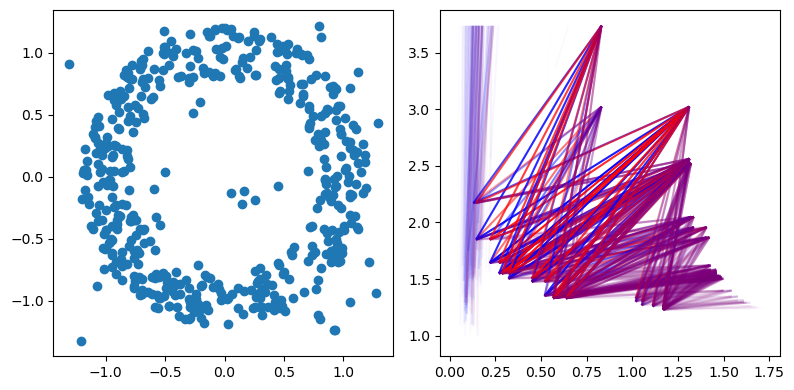

In [2]:
np.random.seed(0)

fig, (a, b) = plt.subplots(ncols=2, figsize=(8, 4))
points = mp.data.noisy_annulus(n1=450, n2=50, r1=0.8, r2=1.2)
a.scatter(*points.T)
rips = mp.filtrations.RipsCodensity(
    points,
    bandwidth=0.15,
)
rips = rips.collapse_edges(-1).expansion(2)
slicer = mp.Slicer(rips).minpres(1)

slicer = slicer.minpres(1)
plt.sca(b)
(rank_sm,) = mpi.signed_measure(
    slicer,
    invariant="rank",
    plot=True,
)

points.shape, len(slicer), len(slicer), rank_sm[0].shape

Randomly draw 10 positive-slope lines through the filtration bounding box,
slice the rank signed measure with `barcode_from_rank_sm`, and compare each
result with direct line persistence on the slicer. Direct persistence can
contain diagonal zero-length bars from the chain model; the rank-signed-measure
slice has already cancelled those, so we remove them before comparing.

In [3]:
num_lines = 10
filtration_box = np.asarray(mp.grids.compute_bounding_box(slicer), dtype=float)
rng = np.random.default_rng(1)
line_labels = [f"L{i:02d}" for i in range(num_lines)]
line_colors = plt.get_cmap("tab20")(np.linspace(0, 1, num_lines))
line_basepoints = rng.uniform(
    low=filtration_box[0],
    high=filtration_box[1],
    size=(num_lines, slicer.num_parameters),
)
line_directions = rng.uniform(
    low=0.2,
    high=1.0,
    size=(num_lines, slicer.num_parameters),
)
line_directions /= line_directions.max(axis=1, keepdims=True)


def finite_nontrivial_barcode(barcode):
    barcode = np.asarray(barcode, dtype=float).reshape(-1, 2)
    return barcode[(barcode[:, 0] < barcode[:, 1]) & np.isfinite(barcode[:, 1])]


def sort_barcode(barcode):
    if len(barcode) == 0:
        return barcode
    death_key = np.nan_to_num(barcode[:, 1], nan=np.inf, posinf=np.inf)
    return barcode[np.lexsort((death_key, barcode[:, 0]))]


rank_barcodes = []
direct_barcodes = []
max_abs_errors = []
for basepoint, direction in zip(line_basepoints, line_directions, strict=True):
    rank_barcode = sort_barcode(
        finite_nontrivial_barcode(
            mp.point_measure.barcode_from_rank_sm(rank_sm, basepoint, direction)
        )
    )
    direct_barcode = sort_barcode(
        finite_nontrivial_barcode(
            slicer.persistence_on_line(basepoint, direction, keep_inf=False)[1]
        )
    )

    np.testing.assert_allclose(rank_barcode, direct_barcode, rtol=0, atol=1e-10)

    if len(rank_barcode):
        max_abs_errors.append(float(np.max(np.abs(rank_barcode - direct_barcode))))
    else:
        max_abs_errors.append(0.0)
    rank_barcodes.append(rank_barcode)
    direct_barcodes.append(direct_barcode)

The left plot shows the rank signed measure as birth-death rectangles. Each
colored line is one affine slice. The right plot shows the finite barcode
recovered from the rank signed measure on that same line; row labels and colors
match the slice labels. The assertions above checked equality with direct
`slicer.persistence_on_line` output for every row.

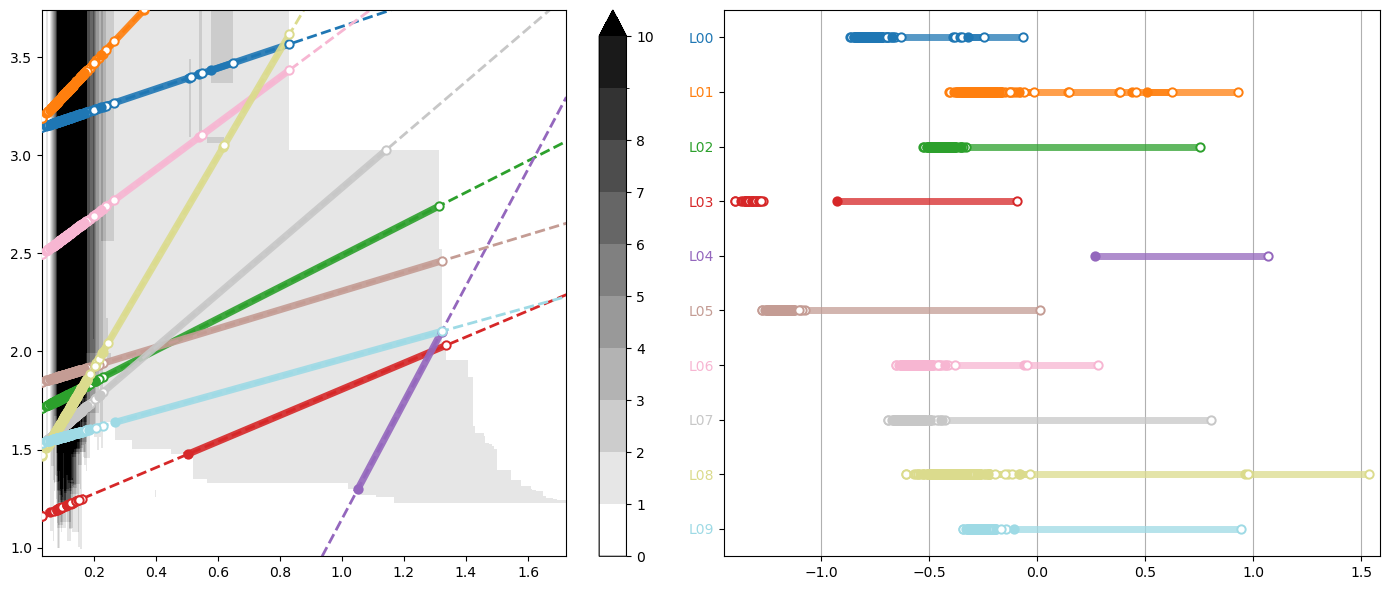

In [4]:
fig, (ax_measure, ax_barcode) = plt.subplots(ncols=2, figsize=(14, 6))

plt.sca(ax_measure)
mp.invariants.hilbert_function(
    slicer,
    plot=True,
)
box = mp.grids.compute_bounding_box(slicer)
ax_measure.set_xlim(*box[:,0])
ax_measure.set_ylim(*box[:,1])
for label, color, basepoint, direction, barcode in zip(
    line_labels,
    line_colors,
    line_basepoints,
    line_directions,
    rank_barcodes,
    strict=True,
):
    ax_measure.axline(
        basepoint,
        slope=direction[1] / direction[0],
        color=color,
        linestyle="--",
        linewidth=2,
        clip_on=True,
    )
    for birth, death in barcode:
        segment = basepoint + np.array([birth, death])[:, None] * direction
        ax_measure.plot(
            segment[:, 0], segment[:, 1], color=color, linewidth=5, alpha=0.9
        )
        ax_measure.scatter(
            segment[0, 0],
            segment[0, 1],
            s=36,
            facecolors=[color],
            edgecolors=color,
            linewidths=1.4,
            zorder=3,
            clip_on=True,
        )
        ax_measure.scatter(
            segment[1, 0],
            segment[1, 1],
            s=36,
            facecolors="white",
            edgecolors=color,
            linewidths=1.4,
            zorder=3,
            clip_on=True,
        )


def draw_barcode_row(ax, barcode, y, color):
    for birth, death in barcode:
        ax.hlines(y, birth, death, color=color, linewidth=5, alpha=0.75)
        ax.scatter(
            birth,
            y,
            s=36,
            facecolors=[color],
            edgecolors=color,
            linewidths=1.4,
            zorder=3,
        )
        ax.scatter(
            death,
            y,
            s=36,
            facecolors="white",
            edgecolors=color,
            linewidths=1.4,
            zorder=3,
        )


for line_index, (barcode, color, label) in enumerate(
    zip(rank_barcodes, line_colors, line_labels, strict=True)
):
    draw_barcode_row(ax_barcode, barcode, line_index, color)
    ax_barcode.plot([], [], color=color, linewidth=5, label=label)

all_endpoints = np.concatenate(
    [barcode.reshape(-1) for barcode in rank_barcodes if len(barcode)]
)
ax_barcode.set_xlim(all_endpoints.min() - 0.05, all_endpoints.max() + 0.05)
ax_barcode.set_ylim(num_lines - 0.5, -0.5)
ax_barcode.set_yticks(np.arange(num_lines))
ax_barcode.set_yticklabels(line_labels)
for tick, color in zip(ax_barcode.get_yticklabels(), line_colors, strict=True):
    tick.set_color(color)
ax_barcode.grid(axis="x")
plt.tight_layout()